# Zero-Day Attack Classification — CICIoT2023 Pilot

**Experiment:** Withhold one attack class entirely from training. Generate binary (normal/attack) rules using the RAG-LLM pipeline on the remaining data. Evaluate on the withheld class at test time to measure zero-day generalisation.

**Key metric:** Zero-Day Detection Rate (ZDR) = fraction of withheld-class entries flagged as 'attack'.

**Pipeline consistency:** Embeddings use BAAI/bge-m3 with cosine similarity to mean — identical to the multiclass evaluation pipeline. Training data uses the same `sample-100000-2.csv` base as all other binary experiments.

**To run a different withheld class:** change `WITHHELD_CLASS` in Cell 0 and restart kernel.

In [ ]:
################################################################################
# Cell 0 — Configuration
################################################################################

# === Change WITHHELD_CLASS to run a different zero-day scenario ===
#
# Recommended candidates for CICIoT2023 (with approximate sample count in dataset):
#   'MITM-ArpSpoofing'   ~596 samples — ARP-layer, distinct from IP-layer floods (RECOMMENDED)
#   'DNS_Spoofing'       ~370 samples — DNS protocol, distinct attack vector
#   'Recon-HostDiscovery' ~264 samples — reconnaissance, low-volume scanning
#   'Backdoor_Malware'    ~11 samples — stealth/persistence (few samples, use for discussion only)
#   'SqlInjection'        ~11 samples — application-layer (few samples)
#
# Selection rationale: MITM-ArpSpoofing operates at the ARP layer with a distinct
# binary feature (ARP=1) and traffic profile orthogonal to the volumetric DDoS/DoS/Mirai
# majority. It has sufficient samples (~596) for statistically meaningful ZDR estimates.

WITHHELD_CLASS = 'MITM-ArpSpoofing'

DATASET_NAME    = 'cic-iot'
SAMPLE_SIZE     = 100000   # base sample file size
N_REPR          = 10       # representative samples per class fed to LLM
MAX_EMBED       = 100      # max rows to embed per class (cap for speed, same as multiclass nb)
k               = 5        # number of rules
n               = 5        # number of feedback iterations
SEEDS           = [42, 123, 456]  # seeds for multi-run error bars
SEED_MAIN       = 42

print(f'Withheld (zero-day) class : {WITHHELD_CLASS}')
print(f'Rules: {k} | Iterations: {n} | Seeds: {SEEDS}')

Withheld (zero-day) class : MITM-ArpSpoofing
Rules: 5 | Iterations: 5 | Seeds: [42, 123, 456]


In [3]:
################################################################################
# Cell 1 — Load data
#
# Single source: cic-iot-2023-population.csv (full dataset with original labels)
# All splits (training, test, zero-day) are derived from this file only.
################################################################################

import pandas as pd
import numpy as np
import os
from tabulate import tabulate

DATA_PATH = '/Users/S4160163/Documents/Projects/RAG Paper/data/cic-iot/CSV/cic-iot-2023-population.csv'
df = pd.read_csv(DATA_PATH)

feature_cols = [c for c in df.columns if c != 'label']

print(f'=== CICIoT2023 Population ===')
print(f'Data path  : {DATA_PATH}')
print(f'Total rows : {len(df):,}')
print(f'Features   : {len(feature_cols)}')
print()

label_counts = df['label'].value_counts()
print('Class distribution:')
print(label_counts.to_string())
print()

benign_count   = label_counts.get('BenignTraffic', 0)
withheld_count = label_counts.get(WITHHELD_CLASS, 0)
print(f'BenignTraffic rows       : {benign_count:,}')
print(f'"{WITHHELD_CLASS}" rows  : {withheld_count:,}')

=== CICIoT2023 Population ===
Data path  : /Users/S4160163/Documents/Projects/RAG Paper/data/cic-iot/CSV/cic-iot-2023-population.csv
Total rows : 1,690,000
Features   : 43

Class distribution:
label
DDoS-ICMP_Flood            261078
DDoS-UDP_Flood             195748
DDoS-TCP_Flood             163428
DDoS-PSHACK_Flood          148218
DDoS-SYN_Flood             147166
DDoS-RSTFINFlood           146691
DDoS-SynonymousIP_Flood    129875
DoS-UDP_Flood              120094
DoS-TCP_Flood               96701
DoS-SYN_Flood               73302
BenignTraffic               39394
Mirai-greeth_flood          36036
Mirai-udpplain              31864
Mirai-greip_flood           27241
DDoS-ICMP_Fragmentation     16295
MITM-ArpSpoofing            11211
DDoS-ACK_Fragmentation      10293
DDoS-UDP_Fragmentation      10283
DNS_Spoofing                 6508
Recon-HostDiscovery          4906
Recon-OSScan                 3524
Recon-PortScan               2910
DoS-HTTP_Flood               2577
VulnerabilityScan  

In [4]:
################################################################################
# Cell 2 — Prepare zero-day split
#
# Balancing strategy:
#   - BenignTraffic is the smallest class — sample attack rows to match its count
#   - This gives a 1:1 normal:attack ratio, avoiding the class imbalance problem
#   - The withheld class is excluded from the training pool entirely
#
# Zero-day test set:
#   - ALL rows of WITHHELD_CLASS (never in training, never in test_known)
################################################################################

benign_df    = df[df['label'] == 'BenignTraffic'].copy()
known_atk_df = df[
    (df['label'] != 'BenignTraffic') & (df['label'] != WITHHELD_CLASS)
].copy()
zeroday_df   = df[df['label'] == WITHHELD_CLASS].copy()

print(f'BenignTraffic rows : {len(benign_df):,}')
print(f'Known attack rows  : {len(known_atk_df):,}  ({known_atk_df["label"].nunique()} classes)')
print(f'Zero-day rows      : {len(zeroday_df):,}  ("{WITHHELD_CLASS}")')

# Balance: sample attack rows to match BenignTraffic count (avoids class imbalance)
n_benign = len(benign_df)
known_atk_sampled = known_atk_df.sample(
    n=min(n_benign, len(known_atk_df)), random_state=SEED_MAIN
)
print(f'\nBalanced pool: {n_benign:,} benign + {len(known_atk_sampled):,} known attack (1:1 ratio)')

# Binary labels
train_pool = pd.concat([benign_df, known_atk_sampled], ignore_index=True)
train_pool['binary_label'] = train_pool['label'].apply(
    lambda x: 'normal' if x == 'BenignTraffic' else 'attack'
)

# Stratified 80/20 split
from sklearn.model_selection import train_test_split
train_idx, test_idx = train_test_split(
    train_pool.index, test_size=0.2, random_state=SEED_MAIN,
    stratify=train_pool['binary_label']
)
train_df      = train_pool.loc[train_idx]
test_known_df = train_pool.loc[test_idx]

# Feature-only dataframes (global — referenced by evaluation_tool and evaluate_node)
normal_df_train = train_df[train_df['binary_label'] == 'normal'][feature_cols].reset_index(drop=True)
attack_df_train = train_df[train_df['binary_label'] == 'attack'][feature_cols].reset_index(drop=True)
normal_df_test  = test_known_df[test_known_df['binary_label'] == 'normal'][feature_cols].reset_index(drop=True)
attack_df_test  = test_known_df[test_known_df['binary_label'] == 'attack'][feature_cols].reset_index(drop=True)

# Zero-day test = ALL withheld class rows (guaranteed absent from training)
zeroday_df_test = zeroday_df[feature_cols].reset_index(drop=True)

data = [
    ['Normal (train)',                    len(normal_df_train)],
    ['Known attack (train)',              len(attack_df_train)],
    ['Normal (test, known)',              len(normal_df_test)],
    ['Known attack (test, known)',        len(attack_df_test)],
    [f'Zero-day test ({WITHHELD_CLASS})', len(zeroday_df_test)],
]
print('\nDataset splits:')
print(tabulate(data, headers=['Split', 'Count'], tablefmt='grid'))
print(f'\nFeatures : {len(feature_cols)}')
print('Zero-day samples are NOT present in training.')

BenignTraffic rows : 39,394
Known attack rows  : 1,639,395  (32 classes)
Zero-day rows      : 11,211  ("MITM-ArpSpoofing")

Balanced pool: 39,394 benign + 39,394 known attack (1:1 ratio)

Dataset splits:
+----------------------------------+---------+
| Split                            |   Count |
+==================================+=========+
| Normal (train)                   |   31515 |
+----------------------------------+---------+
| Known attack (train)             |   31515 |
+----------------------------------+---------+
| Normal (test, known)             |    7879 |
+----------------------------------+---------+
| Known attack (test, known)       |    7879 |
+----------------------------------+---------+
| Zero-day test (MITM-ArpSpoofing) |   11211 |
+----------------------------------+---------+

Features : 43
Zero-day samples are NOT present in training.


In [5]:
################################################################################
# Cell 3 — Representative samples via BGE-M3 embeddings
#
# Identical methodology to 5-evaluation-multiclass-llm.ipynb:
#   1. Subsample up to MAX_EMBED rows per class
#   2. Embed as stringified row lists using BAAI/bge-m3
#   3. Compute mean embedding
#   4. Select top N_REPR rows by cosine similarity to mean
#
# This avoids rebuilding the full Chroma vector store (which was pre-built from
# ALL attack classes and cannot be reused here since WITHHELD_CLASS is excluded).
################################################################################

import json
from langchain_huggingface.embeddings import HuggingFaceEmbeddings
from tqdm import tqdm

embeddings = HuggingFaceEmbeddings(
    model_name='BAAI/bge-m3',
    model_kwargs={'device': 'mps'},
    encode_kwargs={'normalize_embeddings': True, 'batch_size': 64}
)


def get_representative_samples_bge(
    df: pd.DataFrame, n: int = 10, max_embed: int = 100, seed: int = 42
) -> pd.DataFrame:
    """
    Subsample up to max_embed rows, embed using BGE-M3, compute mean embedding,
    return n rows with highest cosine similarity to the mean.
    Mirrors the approach in 5-evaluation-multiclass-llm.ipynb cell 5.
    """
    sample = df.sample(n=min(max_embed, len(df)), random_state=seed)
    docs   = [str(row.tolist()) for _, row in sample.iterrows()]
    vecs   = np.array(embeddings.embed_documents(docs))
    mean_vec = vecs.mean(axis=0)
    # Cosine similarity to mean
    norms = np.linalg.norm(vecs, axis=1) * np.linalg.norm(mean_vec)
    sims  = (vecs @ mean_vec) / np.where(norms == 0, 1e-9, norms)
    top_idx = np.argsort(sims)[::-1][:n]
    return sample.iloc[top_idx]


print('Computing normal representative samples via BGE-M3...')
normal_repr = get_representative_samples_bge(
    normal_df_train, n=N_REPR, max_embed=MAX_EMBED, seed=SEED_MAIN
)

print('Computing attack representative samples via BGE-M3 (known attacks only)...')
attack_repr = get_representative_samples_bge(
    attack_df_train, n=N_REPR, max_embed=MAX_EMBED, seed=SEED_MAIN
)

# Build dicts in the format the LLM prompt expects
normal_entries_dict = {col: normal_repr[col].tolist() for col in feature_cols}
attack_entries_dict = {col: attack_repr[col].tolist() for col in feature_cols}
normal_entries = json.dumps(normal_entries_dict)
attack_entries = json.dumps(attack_entries_dict)

print(f'\nRepresentative normal  samples : {len(normal_repr)}')
print(f'Representative attack  samples : {len(attack_repr)}')
print(f'Embedding model        : BAAI/bge-m3 (normalised cosine, batch=64)')
print(f'Max embedded per class : {MAX_EMBED}  (same cap as multiclass pipeline)')

Computing normal representative samples via BGE-M3...
Computing attack representative samples via BGE-M3 (known attacks only)...

Representative normal  samples : 10
Representative attack  samples : 10
Embedding model        : BAAI/bge-m3 (normalised cosine, batch=64)
Max embedded per class : 100  (same cap as multiclass pipeline)


In [6]:
################################################################################
# Cell 4 — Policy Evaluation Tool (identical to other binary experiments)
################################################################################

import operator as op_module
from tqdm import tqdm
from sklearn.metrics import classification_report, confusion_matrix
from statistics import mode
from typing import Annotated
from langchain_core.tools import tool

show_progress = False
operators = {
    '<':  op_module.lt,
    '>':  op_module.gt,
    '==': op_module.eq,
    '<=': op_module.le,
    '>=': op_module.ge,
    '!=': op_module.ne,
}


@tool
def evaluation_tool(
        feature_name: Annotated[str, 'Feature name'],
        value: Annotated[float, 'Threshold value'],
        op: Annotated[str, 'Operator (<, >, <=, >=, ==, !=)']
) -> float:
    """Evaluate a single threshold rule on training data. Returns macro F1-score."""
    try:
        value = float(value)
    except (ValueError, TypeError):
        pass
    if op not in operators:
        raise ValueError(f'Unsupported operator: {op}')
    datasets = {'normal': normal_df_train, 'attack': attack_df_train}
    y_pred, y_true = [], []
    for label, dataset in datasets.items():
        for i in tqdm(range(len(dataset)), disable=not show_progress,
                      ncols=100, desc=f'Evaluating {label}...'):
            y_true.append(label)
            try:
                y_pred.append('attack' if operators[op](dataset.iloc[i][feature_name], value) else 'normal')
            except (KeyError, TypeError):
                y_pred.append('normal')
    report = classification_report(y_true, y_pred, digits=4, output_dict=True)
    return report['macro avg']['f1-score']


print('evaluation_tool defined.')

evaluation_tool defined.


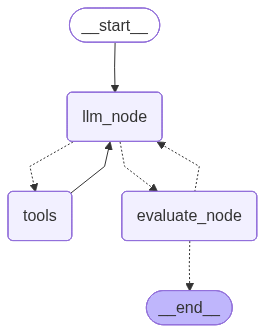

Graph compiled.


In [11]:
################################################################################
# Cell 5 — LangGraph Pipeline
#
# Note: langgraph.prebuilt (ToolNode) is not available in this version of langgraph.
# A minimal custom ToolNode is implemented below that is functionally equivalent.
################################################################################

import dotenv, os, json
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage, ToolMessage
from langchain_openai import ChatOpenAI
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_anthropic import ChatAnthropic
from langgraph.graph import MessagesState, StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver
from IPython.display import Image, display

dotenv.load_dotenv(os.getcwd() + '/../.env')


class State(MessagesState):
    i: int
    max_f1s: float
    best_tool_calls: list


# LLM — same as other binary experiments; comment/uncomment as needed
llm = ChatOpenAI(model='gpt-4o', temperature=0.1)
# llm = ChatGoogleGenerativeAI(model='gemini-1.5-pro', temperature=0.1)
# llm = ChatAnthropic(model='claude-haiku-4-5-20251001', temperature=0.1)

tools_list = [evaluation_tool]
llm_with_tools = llm.bind_tools(tools_list)


def extract_tool_calls(message):
    """Return normalized tool calls from either parsed or raw OpenAI format."""
    parsed = getattr(message, 'tool_calls', None)
    if parsed:
        return parsed

    raw_calls = (getattr(message, 'additional_kwargs', {}) or {}).get('tool_calls', [])
    normalized = []
    for call in raw_calls:
        fn = call.get('function', {})
        args = fn.get('arguments', {})
        if isinstance(args, str):
            try:
                args = json.loads(args)
            except Exception:
                args = {}
        normalized.append({
            'id': call.get('id', ''),
            'name': fn.get('name', ''),
            'args': args,
        })
    return normalized


# Custom ToolNode — replaces langgraph.prebuilt.ToolNode (unavailable in this version)
def make_tool_node(tools):
    tools_by_name = {t.name: t for t in tools}
    def tool_node(state):
        ai_msg = next(
            m for m in reversed(state['messages'])
            if extract_tool_calls(m)
        )
        tool_calls = extract_tool_calls(ai_msg)
        results = []
        for tc in tool_calls:
            result = tools_by_name[tc['name']].invoke(tc['args'])
            results.append(ToolMessage(content=str(result), tool_call_id=tc['id']))
        return {'messages': results}
    return tool_node


def llm_node(state):
    completion = llm_with_tools.invoke(state['messages'])
    return {'messages': [completion], 'i': state['i'] + 1}


def evaluate_node(state):
    """Evaluate current rules on known-attack test set and send feedback to LLM."""
    ai_messages = [
        m for m in state['messages']
        if isinstance(m, AIMessage) and extract_tool_calls(m)
    ]
    if not ai_messages:
        return {}
    tool_calls = extract_tool_calls(ai_messages[-1])

    datasets = {'normal': normal_df_test, 'attack': attack_df_test}
    y_pred, y_true = [], []
    for label, dataset in datasets.items():
        for i in tqdm(range(len(dataset)), disable=False, ncols=100,
                      desc=f'Test eval {label}...'):
            try:
                votes = [
                    'attack' if operators[tc['args']['op']](
                        dataset.iloc[i][tc['args']['feature_name']],
                        float(tc['args']['value'])
                    ) else 'normal'
                    for tc in tool_calls
                ]
                y_pred.append(mode(votes))
            except Exception:
                y_pred.append('normal')
            y_true.append(label)

    report = classification_report(y_true, y_pred, digits=4, output_dict=True)
    matrix = confusion_matrix(y_true, y_pred)
    f1     = report['macro avg']['f1-score']
    print(f'  Iter {state["i"]}: known-attack test macro-F1 = {f1:.4f}')
    print(matrix)

    new_max  = max(state['max_f1s'], f1)
    new_best = tool_calls if f1 >= state['max_f1s'] else state['best_tool_calls']

    feedback = HumanMessage(
        f'Current macro avg F1 on test set (known attacks only): {f1:.4f}. '
        f'Best so far: {new_max:.4f}. '
        f'If this is greater than the previous best, keep performing rules and revise underperforming ones. '
        f'Otherwise revise all rules to exceed the best. '
        f'Generate exactly {k} rules and make a tool call for each.'
    )
    return {
        # For MessagesState, return only new messages to append.
        'messages': [feedback],
        'max_f1s':  new_max,
        'best_tool_calls': new_best,
    }


def tools_condition_edge(state):
    ai_msg = state['messages'][-1]
    return 'tools' if extract_tool_calls(ai_msg) else 'evaluate_node'


def feedback_condition_edge(state):
    return 'llm_node' if state['i'] < n else END


builder = StateGraph(State)
builder.add_node('llm_node', llm_node)
builder.add_node('tools', make_tool_node(tools_list))
builder.add_node('evaluate_node', evaluate_node)

builder.add_edge(START, 'llm_node')
builder.add_conditional_edges('llm_node', tools_condition_edge, ['tools', 'evaluate_node'])
builder.add_edge('tools', 'llm_node')
builder.add_conditional_edges('evaluate_node', feedback_condition_edge, ['llm_node', END])

graph = builder.compile(checkpointer=MemorySaver())
display(Image(graph.get_graph().draw_mermaid_png()))
print('Graph compiled.')

In [12]:
################################################################################
# Cell 6 — Run pipeline (primary seed)
################################################################################

system_message = SystemMessage(
    f"""You are a skilled security data analyst.
You are provided with network data entries categorized as either normal or attack, along with their corresponding feature names.
Carefully analyze the differences between normal and attack entries by comparing corresponding fields.
Your task is to generate exactly {k} simple and deterministic rules for the top {k} important features to filter attack entries.
Supported operators: >, <, >=, <=
NEVER use '==' or '!=' - these are forbidden for numeric features.
Generate exactly {k} rules and make a tool call for each rule."""
)

human_message = HumanMessage(
    f"""Analyze the following network data and generate {k} rules to identify attack entries.

Normal Entries:
```{normal_entries}```

Attack Entries:
```{attack_entries}```"""
)

initial_state = State(
    i=0,
    max_f1s=0.5,
    best_tool_calls=[],
    messages=[system_message, human_message]
)
config = {'configurable': {'thread_id': f'zd-{WITHHELD_CLASS}-seed{SEED_MAIN}'},
          'recursion_limit': 100}

print(f'Running pipeline')
print(f'  Withheld class : {WITHHELD_CLASS}')
print(f'  Seed           : {SEED_MAIN}')
print(f'  Training       : {len(normal_df_train):,} normal + {len(attack_df_train):,} known-attack')
print(f'  Zero-day test  : {len(zeroday_df_test):,} samples of "{WITHHELD_CLASS}"\n')

output = graph.invoke(initial_state, config)

best_tool_calls = output['best_tool_calls']
best_f1 = output['max_f1s']

print(f'\nBest known-attack macro-F1 : {best_f1:.4f}')
print(f'Rules ({len(best_tool_calls)}):')
for tc in best_tool_calls:
    a = tc['args']
    print(f'  {a["feature_name"]:25s} {a["op"]:2s} {a["value"]}')

Running pipeline
  Withheld class : MITM-ArpSpoofing
  Seed           : 42
  Training       : 31,515 normal + 31,515 known-attack
  Zero-day test  : 11,211 samples of "MITM-ArpSpoofing"



Test eval attack...: 100%|████████████████████████████████████| 7879/7879 [00:01<00:00, 7777.30it/s]


  Iter 2: known-attack test macro-F1 = 0.8648
[[5822 2057]
 [  38 7841]]


Test eval attack...: 100%|███████████████████████████████████| 7879/7879 [00:00<00:00, 13142.71it/s]


  Iter 4: known-attack test macro-F1 = 0.6222
[[2599 5280]
 [   7 7872]]


Test eval attack...: 100%|███████████████████████████████████| 7879/7879 [00:00<00:00, 16519.80it/s]


  Iter 6: known-attack test macro-F1 = 0.7926
[[4753 3126]
 [  14 7865]]

Best known-attack macro-F1 : 0.8648
Rules (5):
  flow_duration             <= 1.0
  Header_Length             <= 200.0
  Protocol Type             <= 6.0
  Rate                      <= 5.0
  Tot sum                   <= 600.0


In [13]:
################################################################################
# Cell 7 — Standard binary evaluation on known attacks (sanity check)
################################################################################


def apply_rules_binary(tool_calls, normal_df, attack_df):
    """Majority-vote rule application. Returns (report_dict, confusion_matrix)."""
    y_pred, y_true = [], []
    for label, dataset in [('normal', normal_df), ('attack', attack_df)]:
        for i in tqdm(range(len(dataset)), disable=False, ncols=100, desc=f'Eval {label}...'):
            try:
                votes = [
                    'attack' if operators[tc['args']['op']](
                        dataset.iloc[i][tc['args']['feature_name']], float(tc['args']['value'])
                    ) else 'normal'
                    for tc in tool_calls
                ]
                y_pred.append(mode(votes))
            except Exception:
                y_pred.append('normal')
            y_true.append(label)
    return (
        classification_report(y_true, y_pred, digits=4, output_dict=True),
        confusion_matrix(y_true, y_pred, labels=['normal', 'attack'])
    )


print('=== Standard Binary Evaluation (known attacks only — sanity check) ===')
known_report, known_matrix = apply_rules_binary(
    best_tool_calls, normal_df_test, attack_df_test
)
print(f'Macro F1  : {known_report["macro avg"]["f1-score"]:.4f}')
print(f'Precision : {known_report["macro avg"]["precision"]:.4f}')
print(f'Recall    : {known_report["macro avg"]["recall"]:.4f}')
print(f'\nConfusion matrix (rows=true, cols=pred, order=[normal, attack]):')
print(known_matrix)

=== Standard Binary Evaluation (known attacks only — sanity check) ===


Eval attack...: 100%|█████████████████████████████████████████| 7879/7879 [00:00<00:00, 8075.02it/s]


Macro F1  : 0.8648
Precision : 0.8928
Recall    : 0.8671

Confusion matrix (rows=true, cols=pred, order=[normal, attack]):
[[7841   38]
 [2057 5822]]


In [14]:
################################################################################
# Cell 8 — Zero-day evaluation (the novel test)
################################################################################


def evaluate_zero_day(tool_calls, zd_df: pd.DataFrame):
    """
    Apply rules to the withheld class.
    Returns (ZDR, predictions_list).
    ZDR = fraction of withheld entries flagged as 'attack' (ideally close to 1.0).
    """
    preds = []
    for i in tqdm(range(len(zd_df)), ncols=100,
                  desc=f'Zero-day eval [{WITHHELD_CLASS}]...'):
        try:
            votes = [
                'attack' if operators[tc['args']['op']](
                    zd_df.iloc[i][tc['args']['feature_name']], float(tc['args']['value'])
                ) else 'normal'
                for tc in tool_calls
            ]
            preds.append(mode(votes))
        except Exception:
            preds.append('normal')
    zdr = sum(p == 'attack' for p in preds) / max(len(preds), 1)
    return zdr, preds


llm_zdr, llm_preds = evaluate_zero_day(best_tool_calls, zeroday_df_test)

detected   = sum(p == 'attack' for p in llm_preds)
missed     = sum(p == 'normal' for p in llm_preds)

print(f'\n=== Zero-Day Evaluation: "{WITHHELD_CLASS}" ===')
print(f'Total zero-day samples : {len(zeroday_df_test):,}')
print(f'Detected as attack     : {detected:,}')
print(f'Missed (as normal)     : {missed:,}')
print(f'\nZero-Day Detection Rate (ZDR): {llm_zdr:.4f}  ({llm_zdr*100:.1f}%)')
zdr_label = 'Strong' if llm_zdr > 0.8 else ('Moderate' if llm_zdr > 0.5 else 'Weak')
print(f'Generalisation strength      : {zdr_label}')
print(f'\nInterpretation:')
print(f'  ZDR > 80%: Rules capture abstract attack indicators beyond training profiles')
print(f'  ZDR 50–80%: Partial generalisation')
print(f'  ZDR < 50%: Rules are specific to seen attack profiles, fail on zero-day')

Zero-day eval [MITM-ArpSpoofing]...: 100%|██████████████████| 11211/11211 [00:01<00:00, 9605.80it/s]


=== Zero-Day Evaluation: "MITM-ArpSpoofing" ===
Total zero-day samples : 11,211
Detected as attack     : 244
Missed (as normal)     : 10,967

Zero-Day Detection Rate (ZDR): 0.0218  (2.2%)
Generalisation strength      : Weak

Interpretation:
  ZDR > 80%: Rules capture abstract attack indicators beyond training profiles
  ZDR 50–80%: Partial generalisation
  ZDR < 50%: Rules are specific to seen attack profiles, fail on zero-day


In [15]:
################################################################################
# Cell 9 — ML baseline comparison under same zero-day condition
################################################################################

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

X_train = train_df[feature_cols].values
y_train = train_df['binary_label'].values
X_test  = test_known_df[feature_cols].values
y_test  = test_known_df['binary_label'].values
X_zd    = zeroday_df_test.values

results_summary = []
dt_model, rf_model = None, None

for name, model in [
    ('Decision Tree', DecisionTreeClassifier(random_state=SEED_MAIN)),
    ('Random Forest', RandomForestClassifier(n_estimators=100, random_state=SEED_MAIN, n_jobs=-1)),
]:
    model.fit(X_train, y_train)
    if name == 'Decision Tree': dt_model = model
    if name == 'Random Forest': rf_model = model

    # Standard eval (known classes)
    y_pred_test  = model.predict(X_test)
    rep          = classification_report(y_test, y_pred_test, output_dict=True)
    known_f1     = rep['macro avg']['f1-score']

    # Zero-day eval
    y_pred_zd = model.predict(X_zd)
    ml_zdr    = (y_pred_zd == 'attack').mean()

    results_summary.append([name, f'{known_f1:.4f}', f'{ml_zdr:.4f}  ({ml_zdr*100:.1f}%)'])
    print(f'{name:20s}  known-F1 = {known_f1:.4f}  |  ZDR = {ml_zdr:.4f}')

# Add LLM result at top
results_summary.insert(0, [
    'LLM-generated rules',
    f'{known_report["macro avg"]["f1-score"]:.4f}',
    f'{llm_zdr:.4f}  ({llm_zdr*100:.1f}%)'
])

Decision Tree         known-F1 = 0.9947  |  ZDR = 0.5546
Random Forest         known-F1 = 0.9964  |  ZDR = 0.2201


In [16]:
################################################################################
# Cell 10 — Results summary table + save to disk
################################################################################

import json, datetime

print(f'\n=== ZERO-DAY EXPERIMENT RESULTS ===')
print(f'Dataset  : CICIoT2023')
print(f'Withheld : {WITHHELD_CLASS}  ({len(zeroday_df_test)} zero-day test samples)')
print(f'Seed     : {SEED_MAIN}')
print()
print(tabulate(
    results_summary,
    headers=['Method', 'Known-Attack F1', f'ZDR — {WITHHELD_CLASS}'],
    tablefmt='grid'
))

# Save rules and results
os.makedirs('results/llm', exist_ok=True)
ts = datetime.datetime.now().strftime('%Y-%m-%d-%H-%M-%S')
out = {
    'withheld_class': WITHHELD_CLASS,
    'seed': SEED_MAIN,
    'zero_day_samples': len(zeroday_df_test),
    'known_f1_llm': known_report['macro avg']['f1-score'],
    'zdr_llm': llm_zdr,
    'rules': [tc['args'] for tc in best_tool_calls],
}
with open(f'results/llm/zeroday-{WITHHELD_CLASS}-seed{SEED_MAIN}-{ts}.json', 'w') as f:
    json.dump(out, f, indent=2)
print(f'\nResults saved to results/llm/zeroday-{WITHHELD_CLASS}-seed{SEED_MAIN}-{ts}.json')


=== ZERO-DAY EXPERIMENT RESULTS ===
Dataset  : CICIoT2023
Withheld : MITM-ArpSpoofing  (11211 zero-day test samples)
Seed     : 42

+---------------------+-------------------+--------------------------+
| Method              |   Known-Attack F1 | ZDR — MITM-ArpSpoofing   |
+=====================+===================+==========================+
| LLM-generated rules |            0.8648 | 0.0218  (2.2%)           |
+---------------------+-------------------+--------------------------+
| Decision Tree       |            0.9947 | 0.5546  (55.5%)          |
+---------------------+-------------------+--------------------------+
| Random Forest       |            0.9964 | 0.2201  (22.0%)          |
+---------------------+-------------------+--------------------------+

Results saved to results/llm/zeroday-MITM-ArpSpoofing-seed42-2026-04-20-10-59-17.json


In [17]:
################################################################################
# Cell 11 — Multi-seed runs for error bars
#
# Re-runs the embedding + pipeline for SEEDS and computes mean ± std ZDR.
# Note: representative samples differ per seed because get_representative_samples_bge
# is called with seed=s, introducing controlled variation.
################################################################################

seed_results = []

for s in SEEDS:
    print(f'\n--- Seed {s} ---')

    # Recompute representative samples with this seed
    n_repr_s  = get_representative_samples_bge(normal_df_train, n=N_REPR, max_embed=MAX_EMBED, seed=s)
    a_repr_s  = get_representative_samples_bge(attack_df_train, n=N_REPR, max_embed=MAX_EMBED, seed=s)
    n_entries = json.dumps({col: n_repr_s[col].tolist() for col in feature_cols})
    a_entries = json.dumps({col: a_repr_s[col].tolist() for col in feature_cols})

    # Fresh graph instance per seed
    g = builder.compile(checkpointer=MemorySaver())
    state_s = State(
        i=0, max_f1s=0.5, best_tool_calls=[],
        messages=[
            SystemMessage(system_message.content),
            HumanMessage(
                f'Analyze the following network data and generate {k} rules to identify attack entries.\n\n'
                f'Normal Entries:\n```{n_entries}```\n\n'
                f'Attack Entries:\n```{a_entries}```'
            )
        ]
    )
    cfg_s = {'configurable': {'thread_id': f'zd-{WITHHELD_CLASS}-seed{s}'}, 'recursion_limit': 100}
    out_s = g.invoke(state_s, cfg_s)

    best_s = out_s['best_tool_calls']
    zdr_s, _ = evaluate_zero_day(best_s, zeroday_df_test)
    known_s_report, _ = apply_rules_binary(best_s, normal_df_test, attack_df_test)
    seed_results.append({
        'seed': s,
        'known_f1': known_s_report['macro avg']['f1-score'],
        'zdr': zdr_s
    })
    print(f'  Known-F1: {known_s_report["macro avg"]["f1-score"]:.4f}  |  ZDR: {zdr_s:.4f}')

zdr_vals    = [r['zdr']      for r in seed_results]
known_vals  = [r['known_f1'] for r in seed_results]
print(f'\n=== Multi-seed summary (n={len(SEEDS)}) ===')
print(f'Known-attack F1 : {np.mean(known_vals):.4f} ± {np.std(known_vals):.4f}')
print(f'ZDR             : {np.mean(zdr_vals):.4f} ± {np.std(zdr_vals):.4f}')


--- Seed 42 ---


Test eval attack...: 100%|████████████████████████████████████| 7879/7879 [00:01<00:00, 6979.89it/s]


  Iter 2: known-attack test macro-F1 = 0.8202
[[5312 2567]
 [ 202 7677]]


Test eval attack...: 100%|███████████████████████████████████| 7879/7879 [00:00<00:00, 12636.81it/s]


  Iter 4: known-attack test macro-F1 = 0.8452
[[5735 2144]
 [ 261 7618]]


...

  Iter 4: known-attack test macro-F1 = 0.8543
[[5642 2237]
 [  14 7865]]


Test eval attack...: 100%|███████████████████████████████████| 7879/7879 [00:00<00:00, 15346.62it/s]


  Iter 6: known-attack test macro-F1 = 0.8478
[[5543 2336]
 [  10 7869]]


Eval attack...: 100%|████████████████████████████████████████| 7879/7879 [00:00<00:00, 13921.13it/s]


  Known-F1: 0.8543  |  ZDR: 0.0054

=== Multi-seed summary (n=3) ===
Known-attack F1 : 0.8390 ± 0.0166
ZDR             : 0.0243 ± 0.0304


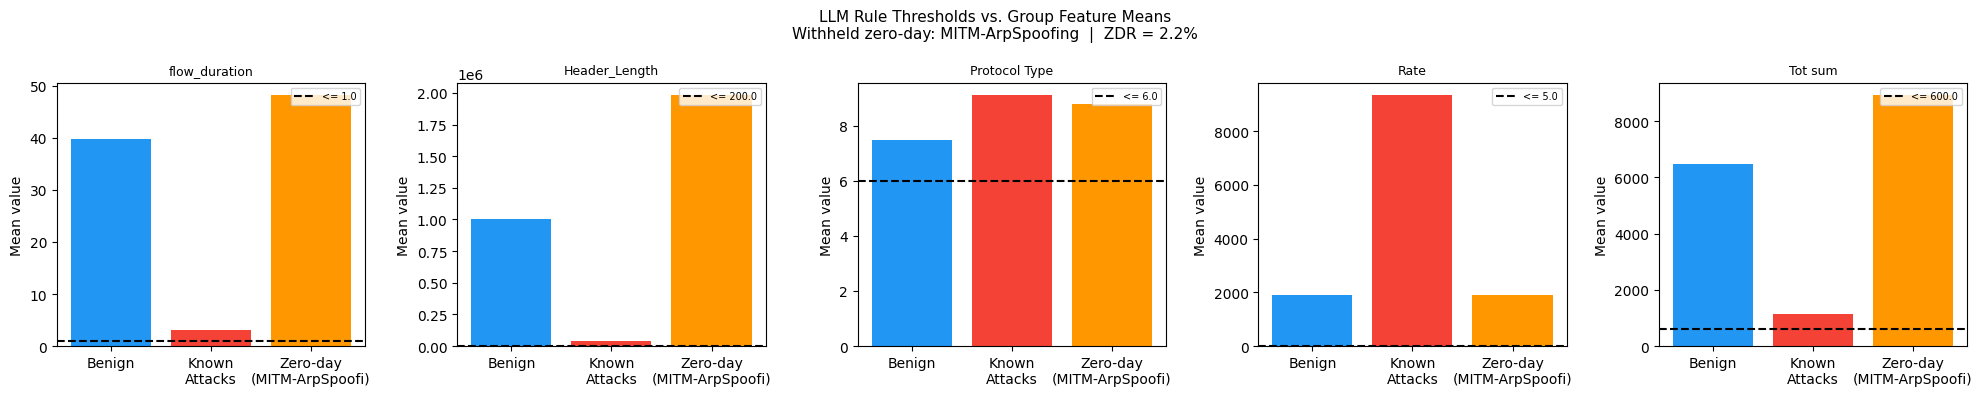

Figure saved.


In [19]:
################################################################################
# Cell 12 — Visualise: rule thresholds vs mean feature values per group
################################################################################

import matplotlib.pyplot as plt

rule_features = [tc['args']['feature_name'] for tc in best_tool_calls]
rule_ops      = [tc['args']['op']           for tc in best_tool_calls]
rule_values   = [tc['args']['value']        for tc in best_tool_calls]

# Mean feature value per group for rule features only
benign_means  = normal_df_train[rule_features].mean()
known_means   = attack_df_train[rule_features].mean()
zd_means      = zeroday_df_test[rule_features].mean()

n_rules = len(rule_features)
fig, axes = plt.subplots(1, n_rules, figsize=(4 * n_rules, 4))
if n_rules == 1:
    axes = [axes]

for ax, feat, op_str, thresh in zip(axes, rule_features, rule_ops, rule_values):
    ax.bar(
        ['Benign', 'Known\nAttacks', f'Zero-day\n({WITHHELD_CLASS[:14]})'],
        [benign_means[feat], known_means[feat], zd_means[feat]],
        color=['#2196F3', '#F44336', '#FF9800']
    )
    ax.axhline(y=float(thresh), color='black', linestyle='--', linewidth=1.5,
               label=f'{op_str} {thresh}')
    ax.set_title(feat, fontsize=9)
    ax.set_ylabel('Mean value')
    ax.legend(fontsize=7, loc='upper right')

fig.suptitle(
    f'LLM Rule Thresholds vs. Group Feature Means\n'
    f'Withheld zero-day: {WITHHELD_CLASS}  |  ZDR = {llm_zdr*100:.1f}%',
    fontsize=11
)
plt.tight_layout()
os.makedirs('results', exist_ok=True)
plt.savefig(f'results/zeroday-{WITHHELD_CLASS}-thresholds.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved.')